#SAUDI ARABIAN USED CAR
>By Muhammad Fachreza Alghifari

[Dataset SAUDI ARABIAN USED CAR](https://drive.google.com/file/d/1Tr4YT5dmgwTrXLvIqZ4diBf5z8K6JjrR/view?usp=drive_link)

#**Business Problem Understanding**


---


## Context
Syarah.com is a Saudi Arabian online marketplace that specializes in buying and selling used cars. The platform connects individual car sellers with potential buyers across multiple regions in Saudi Arabia, acting as a third-party intermediary — similar to how Airbnb connects hosts with guests. The used car market in Saudi Arabia is substantial, with consumers frequently turning to platforms like Syarah.com as their primary channel for vehicle transactions.

On this platform, sellers are given full freedom to list their cars along with a price of their own choosing. However, unlike new car dealerships that follow manufacturer pricing, the used car market has no fixed price standard. Every car is unique in its condition, history, and specifications — making accurate pricing genuinely difficult for the average seller.

---

## Problem
One of the biggest challenges for a marketplace like Syarah.com is ensuring that listings are priced fairly and competitively. When sellers list their cars, most rely on personal estimation rather than data-driven market insight. They may base their price on what they originally paid, a rough depreciation calculation, or simply what feels right — without accounting for how factors like mileage, engine size, manufacturing year, region, and car origin collectively influence a vehicle's true market value.

This leads to two problematic outcomes: sellers who overprice their cars see their listings sit unsold for extended periods, reducing the platform's transaction completion rate. Sellers who underprice may sell quickly but feel undervalued, reducing long-term seller retention. Both outcomes directly reduce the volume of successful transactions on Syarah.com — which is the primary driver of the platform's revenue.


---

## Goal
Based on this problem, Syarah.com needs a tool that can predict the fair market price of a used car based on its specifications, so that sellers receive an automated price recommendation at the time of listing. This recommendation would help sellers set competitive and accurate prices without requiring deep market knowledge.

For Syarah.com, a price prediction tool that generates fair recommendations can increase the number of completed transactions and improve both seller and buyer satisfaction. More completed transactions directly translates to higher platform revenue. Additionally, since this model is built on Syarah.com's proprietary historical transaction data, it represents a competitive advantage that other platforms or external parties cannot easily replicate.

This model is expected to assist sellers in setting prices within a reasonable error range, improving listing competitiveness and increasing successful transactions on the platform.


---

## Analytic Approach
What we need to do is analyze the data to find patterns across the car features that differentiate one listing from another in terms of price. We will then build a regression model that helps Syarah.com provide a price prediction tool for newly listed used cars — which will assist sellers in determining the right asking price for their vehicle.

This is a supervised regression problem because the target variable — Price — is a continuous numerical value representing the car's market price in Saudi Arabian Riyals (SAR).


---



##Metric Evaluation
The evaluation metrics that will be used are RMSE, MAE, and MAPE. RMSE (Root Mean Squared Error) is the square root of the average of squared errors — it penalizes large errors more heavily than small ones. MAE (Mean Absolute Error) is the average of the absolute differences between predicted and actual values, giving a straightforward measure of average prediction error in SAR. MAPE (Mean Absolute Percentage Error) is the average percentage error produced by the model, making it easy to interpret regardless of price scale.

The smaller the RMSE, MAE, and MAPE values, the more accurate the model is at predicting used car prices within the limitations of the features used. If the final model selected is a linear model, we can additionally use R-squared to measure how well the model represents the overall variance in the data — though this metric is not valid for non-linear models.


---



## The Limit
It is important to note the limitations of this model. The model is trained exclusively on historical listing data from syarah.com and reflects market conditions within Saudi Arabia at the time of data collection. It may not accurately predict prices for vehicle types not represented in the dataset — notably electric vehicles, which are increasingly influencing global used car market dynamics but are not yet present in this dataset. Additionally, external factors such as fuel price fluctuations, government import regulations, and macroeconomic conditions in Saudi Arabia can affect car prices in ways the model cannot account for without retraining on updated data.

---



# Exploration and Cleaning Data

## Exploration Data

In [21]:
#Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [22]:
#Import Data
df = pd.read_csv("/content/data_saudi_used_cars.csv")
df

,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Negotiable,Price
0,Corolla,Abha,Toyota,Manual,Saudi,Standard,2013,1.4,421000,True,0
1,Yukon,Riyadh,GMC,Automatic,Saudi,Full,2014,8.0,80000,False,120000
2,Range Rover,Riyadh,Land Rover,Automatic,Gulf Arabic,Full,2015,5.0,140000,False,260000
3,Optima,Hafar Al-Batin,Kia,Automatic,Saudi,Semi Full,2015,2.4,220000,False,42000
4,FJ,Riyadh,Toyota,Automatic,Saudi,Full,2020,4.0,49000,True,0
...,...,...,...,...,...,...,...,...,...,...,...
5619,X-Trail,Jeddah,Nissan,Automatic,Saudi,Standard,2018,2.5,78794,False,68000
5620,Altima,Jeddah,Nissan,Automatic,Saudi,Semi Full,2020,2.5,58000,True,0
5621,Yukon,Dammam,GMC,Automatic,Saudi,Full,2016,5.3,48000,False,145000
5622,RX,Dammam,Lexus,Automatic,Gulf Arabic,Full,2016,2.5,81000,False,154000


In [23]:
#Exploration Data
print("info")
df.info()


info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5624 entries, 0 to 5623
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Type         5624 non-null   object 
 1   Region       5624 non-null   object 
 2   Make         5624 non-null   object 
 3   Gear_Type    5624 non-null   object 
 4   Origin       5624 non-null   object 
 5   Options      5624 non-null   object 
 6   Year         5624 non-null   int64  
 7   Engine_Size  5624 non-null   float64
 8   Mileage      5624 non-null   int64  
 9   Negotiable   5624 non-null   bool   
 10  Price        5624 non-null   int64  
dtypes: bool(1), float64(1), int64(3), object(6)
memory usage: 445.0+ KB


In [24]:
print("describe")
df.describe()

describe


,Year,Engine_Size,Mileage,Price
count,5624.000000,5624.000000,5.624000e+03,5624.000000
mean,2014.101885,3.295430,1.509234e+05,53074.058144
std,5.791606,1.515108,3.828360e+05,70155.340614
min,1963.000000,1.000000,1.000000e+02,0.000000
25%,2012.000000,2.000000,3.800000e+04,0.000000
50%,2016.000000,3.000000,1.030000e+05,36500.000000
75%,2018.000000,4.500000,1.960000e+05,72932.500000
max,2022.000000,9.000000,2.000000e+07,850000.000000


In [25]:
print("null value cheacking")
df.isnull().sum()

null value cheacking


,0
Type,0
Region,0
Make,0
Gear_Type,0
Origin,0
Options,0
Year,0
Engine_Size,0
Mileage,0
Negotiable,0


### Target Distribution (Price)

/tmp/ipykernel_6151/4133158944.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Price'])


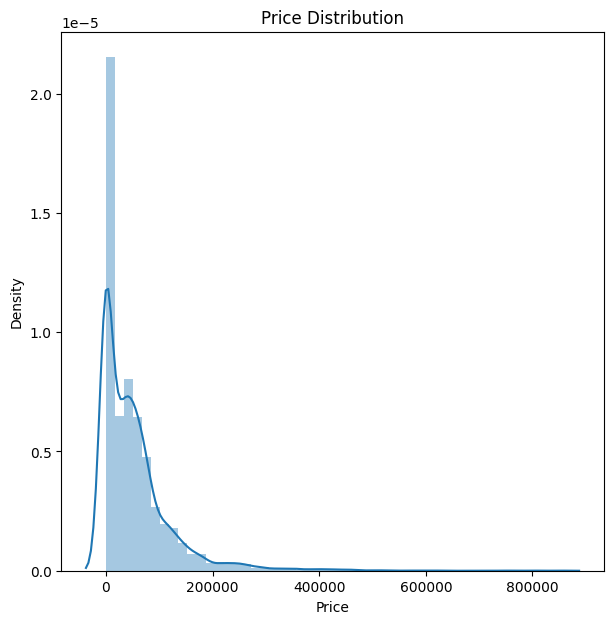

In [26]:
plt.figure(figsize=(7, 7))
sns.distplot(df['Price'])
plt.title('Price Distribution')
plt.show()

From here we can see that the distribution are right skewed distribution, witch means that there`s positif skewness on feature price

In [27]:
# Data for the price that are '0' (negotiable)
zero_price_cars = df[df['Price'] == 0]

print(f"Number of cars with a price of 0: {len(zero_price_cars)}")
print("\nTop 10 Makes for cars with a price of 0:")
display(zero_price_cars['Make'].value_counts().head())

Number of cars with a price of 0: 1797

Top 10 Makes for cars with a price of 0:


,count
Make,
Toyota,542
Ford,184
Chevrolet,162
Hyundai,156
Nissan,135


In [28]:
zero_price_cars

,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Negotiable,Price
0,Corolla,Abha,Toyota,Manual,Saudi,Standard,2013,1.4,421000,True,0
4,FJ,Riyadh,Toyota,Automatic,Saudi,Full,2020,4.0,49000,True,0
9,LS,Aseer,Lexus,Automatic,Saudi,Full,1998,4.6,300,True,0
14,Hilux,Yanbu,Toyota,Automatic,Saudi,Full,2014,2.7,209,True,0
15,Land Cruiser,Aseer,Toyota,Manual,Gulf Arabic,Semi Full,1982,4.6,340000,True,0
...,...,...,...,...,...,...,...,...,...,...,...
5610,Town Car,Jeddah,Lincoln,Automatic,Other,Full,1999,5.0,343,True,0
5614,Victoria,Makkah,Ford,Automatic,Saudi,Standard,2010,4.6,345000,True,0
5617,Yukon,Jubail,GMC,Automatic,Saudi,Semi Full,2006,5.3,300,True,0
5620,Altima,Jeddah,Nissan,Automatic,Saudi,Semi Full,2020,2.5,58000,True,0


In [29]:
neg_cars = df[df['Negotiable'] == True]

print('Top Makes with negotiable listings:')
print(neg_cars['Make'].value_counts().head(10))

print('\nNegotiable by Origin:')
print(neg_cars['Origin'].value_counts())

print('\nNegotiable by Transmition:')
print(neg_cars['Gear_Type'].value_counts())

Top Makes with negotiable listings:
Make
Toyota       541
Ford         184
Chevrolet    162
Hyundai      156
Nissan       135
GMC          115
Lexus         76
Kia           64
Mercedes      53
Mazda         37
Name: count, dtype: int64

Negotiable by Origin:
Origin
Saudi          1292
Other           257
Gulf Arabic     202
Unknown          45
Name: count, dtype: int64

Negotiable by Transmition:
Gear_Type
Automatic    1451
Manual        345
Name: count, dtype: int64


### Checking feature relationship

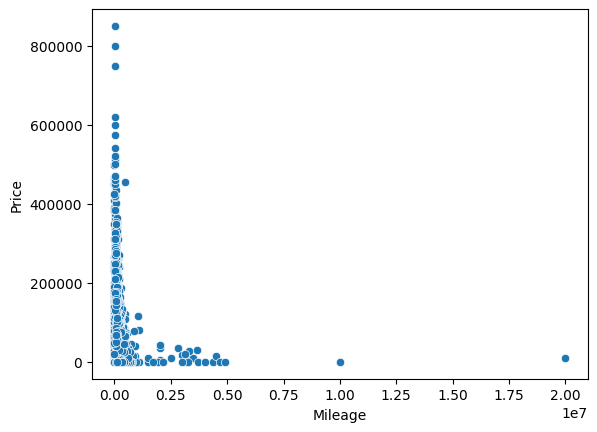

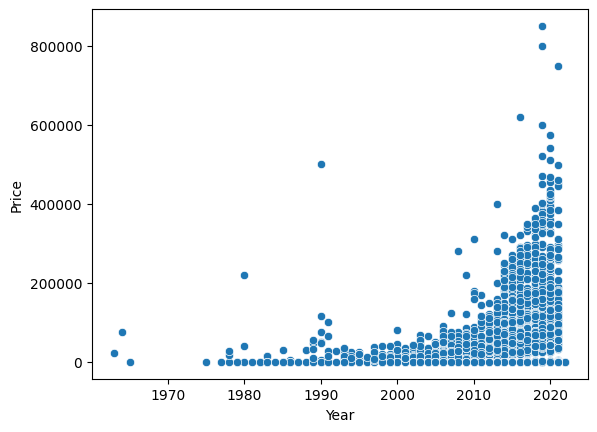

In [30]:
import seaborn as sns

sns.scatterplot(x='Mileage', y='Price', data=df)
plt.show()

sns.scatterplot(x='Year', y='Price', data=df)
plt.show()

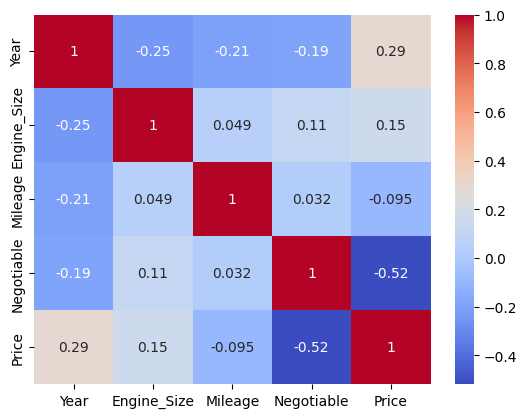

In [31]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

## Cleaning Data

In [32]:
df_model = df.copy()
df_model.shape

(5624, 11)

#### Handle Negotiable Listings

Rows where `Negotiable = True` have `Price = 0` — the seller did not
disclose an asking price. Rather than dropping 32% of the dataset —
which would bias the model toward cars with confident sellers — we
estimate the price using the median price of the same Make, Type, and
Year combination from non-negotiable listings.

Fallback strategy when no exact match exists:
- Level 1: median of same Make + Type + Year (most accurate)
- Level 2: median of same Make + Type
- Level 3: median of same Make + Year
- Level 4: median of same Make
- Level 5: global median (last resort)

After filling, the Negotiable column is dropped.

In [33]:
df_known = df_model[df_model['Negotiable'] == False]
df_neg   = df_model[df_model['Negotiable'] == True].copy()

print(f'Rows with known price:       {len(df_known)}')
print(f'Rows with negotiable price:  {len(df_neg)}')

# Build median lookup tables from known prices only
median_mty = df_known.groupby(['Make','Type','Year'])['Price'].median()
median_mt  = df_known.groupby(['Make','Type'])['Price'].median()
median_my  = df_known.groupby(['Make','Year'])['Price'].median()
median_m   = df_known.groupby('Make')['Price'].median()
global_med = df_known['Price'].median()

def fill_negotiable_price(row):
    k3  = (row['Make'], row['Type'], row['Year'])
    k2  = (row['Make'], row['Type'])
    k2b = (row['Make'], row['Year'])
    k1  = row['Make']
    if   k3  in median_mty.index: return median_mty[k3]
    elif k2  in median_mt.index:  return median_mt[k2]
    elif k2b in median_my.index:  return median_my[k2b]
    elif k1  in median_m.index:   return median_m[k1]
    else:                         return global_med

df_neg['Price'] = df_neg.apply(fill_negotiable_price, axis=1)

df_model = pd.concat([df_known, df_neg], ignore_index=True)
df_model = df_model.drop(columns=['Negotiable'])

print(f'\nShape after filling:     {df_model.shape}')
print(f'Remaining Price = 0:     {(df_model["Price"] == 0).sum()}')

Rows with known price:       3828
Rows with negotiable price:  1796

Shape after filling:     (5624, 10)
Remaining Price = 0:     1


#### Drop Duplicates

In [34]:
print('Duplicate rows:', df_model.duplicated().sum())
df_model = df_model.drop_duplicates()
print('Shape after dropping duplicates:', df_model.shape)

Duplicate rows: 6
Shape after dropping duplicates: (5618, 10)


#### Handle Price Outliers

The Price distribution is right-skewed (skewness = 3.1) due to
legitimate high-value vehicles in the Saudi market. We use a
percentile-based filter (1st–99th percentile) rather than IQR
because IQR would incorrectly flag valid luxury cars like the
Toyota Land Cruiser and Lexus RX as outliers. The percentile
approach only removes genuine data entry errors at the bottom
and ultra-luxury exotics like Rolls-Royce and Bentley at the top.

In [35]:
low_price  = df_model['Price'].quantile(0.01)
high_price = df_model['Price'].quantile(0.99)

print(f'Keeping prices between SAR {low_price:,.0f} and SAR {high_price:,.0f}')
print(f'Rows removed: {df_model[(df_model["Price"] < low_price) | (df_model["Price"] > high_price)].shape[0]}')

df_model = df_model[
    (df_model['Price'] >= low_price) &
    (df_model['Price'] <= high_price)
]
print('Shape after price filter:', df_model.shape)

Keeping prices between SAR 2,052 and SAR 365,000
Rows removed: 113
Shape after price filter: (5505, 10)


#### Handle Mileage Outliers

The Mileage column contains a maximum value of 20,000,000 km —
physically impossible for a road vehicle and clearly a data entry
error. We apply the same percentile filter to remove extreme
values at both ends.

In [36]:
low_mil  = df_model['Mileage'].quantile(0.01)
high_mil = df_model['Mileage'].quantile(0.99)

print(f'Keeping mileage between {low_mil:,.0f} and {high_mil:,.0f} km')
print(f'Rows removed: {df_model[(df_model["Mileage"] < low_mil) | (df_model["Mileage"] > high_mil)].shape[0]}')

df_model = df_model[
    (df_model['Mileage'] >= low_mil) &
    (df_model['Mileage'] <= high_mil)
]
print('Shape after mileage filter:', df_model.shape)

Keeping mileage between 116 and 600,000 km
Rows removed: 105
Shape after mileage filter: (5400, 10)


#### Feature Engineering: Car_Age

The raw Year column tells us the manufacturing year, but what
directly affects price is how old the car is — depreciation is
a function of age, not year. We create `Car_Age = 2026 - Year`
to make this relationship explicit. The original Year column is
dropped as it is now redundant.

In [37]:
df_model['Car_Age'] = 2026 - df_model['Year']
df_model = df_model.drop(columns=['Year'])

print('Car_Age distribution:')
print(df_model['Car_Age'].describe())

Car_Age distribution:
count    5400.000000
mean       11.928889
std         5.687072
min         4.000000
25%         8.000000
50%        10.000000
75%        14.000000
max        63.000000
Name: Car_Age, dtype: float64


#### Feature Engineering: Group Rare Car Types

The Type column contains 320 unique car model names. Of these,
238 appear fewer than 10 times — the model cannot learn reliable
pricing patterns from types it has seen fewer than 10 times.
These are grouped into a single 'Other' category, reducing unique
values from 320 to 81 while preserving the signal from common
types like Camry, Land Cruiser, and Hilux.

In [38]:
type_counts = df_model['Type'].value_counts()
rare_types  = type_counts[type_counts < 10].index

print(f'Unique types before grouping: {df_model["Type"].nunique()}')
df_model['Type'] = df_model['Type'].apply(
    lambda x: 'Other' if x in rare_types else x
)
print(f'Unique types after grouping:  {df_model["Type"].nunique()}')

Unique types before grouping: 337
Unique types after grouping:  97


#### Clean Dataset Summary

In [39]:
print('=== FINAL CLEAN DATASET ===')
print(f'Shape: {df_model.shape}')
print(f'\nMissing values:\n{df_model.isnull().sum()}')
print(f'\nData types:\n{df_model.dtypes}')
df_model.head()

=== FINAL CLEAN DATASET ===
Shape: (5400, 10)

Missing values:
Type           0
Region         0
Make           0
Gear_Type      0
Origin         0
Options        0
Engine_Size    0
Mileage        0
Price          0
Car_Age        0
dtype: int64

Data types:
Type            object
Region          object
Make            object
Gear_Type       object
Origin          object
Options         object
Engine_Size    float64
Mileage          int64
Price          float64
Car_Age          int64
dtype: object


,Type,Region,Make,Gear_Type,Origin,Options,Engine_Size,Mileage,Price,Car_Age
0,Yukon,Riyadh,GMC,Automatic,Saudi,Full,8.0,80000,120000.0,12
1,Range Rover,Riyadh,Land Rover,Automatic,Gulf Arabic,Full,5.0,140000,260000.0,11
2,Optima,Hafar Al-Batin,Kia,Automatic,Saudi,Semi Full,2.4,220000,42000.0,11
3,Other,Abha,Mazda,Automatic,Saudi,Semi Full,2.0,25000,58000.0,7
4,Other,Riyadh,Porsche,Automatic,Saudi,Full,4.8,189000,85000.0,14


# Modeling

We benchmark two state-of-the-art gradient boosting algorithms:

- **XGBoost** — industry standard gradient boosting, highly effective
  on structured tabular data. Builds trees sequentially where each
  tree learns from the errors of the previous one.
- **CatBoost** — specifically designed for datasets with many
  categorical features. Handles high-cardinality columns natively
  without requiring manual encoding.

Linear Regression was considered but excluded because used car pricing
relationships are non-linear — price does not decrease evenly with
age or mileage.

For encoding we use **CatBoost Encoder** — a target-based encoding
method that converts each categorical value into a single numerical
value based on its relationship with Price. This keeps the feature
space compact compared to One-Hot Encoding, which would create 164+
new columns for Make, Type, and Region alone.

In [40]:
!pip install catboost category_encoders -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 6.1 MB/s eta 0:00:00


In [41]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error
from category_encoders import CatBoostEncoder
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import numpy as np
import warnings
warnings.filterwarnings('ignore')

#### Define Features and Target

In [42]:
X = df_model.drop(columns=['Price'])
y = df_model['Price']

print(f'Features shape: {X.shape}')
print(f'Target shape:   {y.shape}')
print(f'\nFeature columns: {list(X.columns)}')

Features shape: (5400, 9)
Target shape:   (5400,)

Feature columns: ['Type', 'Region', 'Make', 'Gear_Type', 'Origin', 'Options', 'Engine_Size', 'Mileage', 'Car_Age']


#### Train-Test Split

We use an 80/20 split — 80% for training and 20% for testing.
`random_state=42` ensures the split is reproducible.

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {X_train.shape}')
print(f'Test set:     {X_test.shape}')

Training set: (4320, 9)
Test set:     (1080, 9)


#### Evaluation Helper

A consistent function to calculate RMSE, MAE, and MAPE
across all models.

- **RMSE** — penalizes large errors more heavily, sensitive to extreme mispredictions
- **MAE** — average error in SAR, easy to interpret for business stakeholders  
- **MAPE** — percentage error, useful for comparing across different price ranges

In [44]:
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f'{name:<30} RMSE: {rmse:>10,.0f} | MAE: {mae:>10,.0f} | MAPE: {mape:>6.1f}%')
    return {'Model': name, 'RMSE': round(rmse), 'MAE': round(mae), 'MAPE': round(mape, 1)}

#### Benchmark — XGBoost vs CatBoost

Both models are tested using CatBoost Encoder inside a Pipeline.
The encoder is fit only on training data — applied to test data
separately — preventing target leakage.

In [45]:
cat_cols = ['Type', 'Region', 'Make', 'Origin', 'Gear_Type', 'Options']
scores   = []

# XGBoost
xgb_pipe = Pipeline([
    ('enc',   CatBoostEncoder(cols=cat_cols, random_state=42)),
    ('model', XGBRegressor(n_estimators=100, random_state=42, verbosity=0))
])
xgb_pipe.fit(X_train, y_train)
scores.append(evaluate('XGBoost (benchmark)', y_test, xgb_pipe.predict(X_test)))

# CatBoost
cb_pipe = Pipeline([
    ('enc',   CatBoostEncoder(cols=cat_cols, random_state=42)),
    ('model', CatBoostRegressor(iterations=100, random_state=42, verbose=0))
])
cb_pipe.fit(X_train, y_train)
scores.append(evaluate('CatBoost (benchmark)', y_test, cb_pipe.predict(X_test)))

XGBoost (benchmark)            RMSE:     23,888 | MAE:     14,731 | MAPE:   35.6%
CatBoost (benchmark)           RMSE:     23,721 | MAE:     14,585 | MAPE:   36.4%


In [46]:
# Benchmark summary
benchmark_df = pd.DataFrame(scores).sort_values('RMSE').reset_index(drop=True)
print('\nBenchmark Results:')
benchmark_df


Benchmark Results:


,Model,RMSE,MAE,MAPE
0,CatBoost (benchmark),23721,14585,36.4
1,XGBoost (benchmark),23888,14731,35.6


#### Hyperparameter Tuning

The better performing model from the benchmark is selected for tuning
using RandomizedSearchCV with 5-fold cross validation. We search over
a defined parameter grid to find the combination that minimizes RMSE.

**Note:** After running the benchmark above, check which model has
lower RMSE and set `use_model = 'xgb'` or `use_model = 'catboost'`
in the cell below accordingly.

In [48]:
# ── SET THIS based on benchmark results above ──────────────────
use_model = 'catboost'
# ───────────────────────────────────────────────────────────────

if use_model == 'xgb':
    base_pipe   = xgb_pipe
    param_grid  = {
        'model__n_estimators':     [100, 200, 300, 500],
        'model__max_depth':        [3, 5, 7, 9],
        'model__learning_rate':    [0.01, 0.05, 0.1, 0.2],
        'model__subsample':        [0.6, 0.8, 1.0],
        'model__colsample_bytree': [0.6, 0.8, 1.0],
        'model__min_child_weight': [1, 3, 5]
    }
else:
    base_pipe   = cb_pipe
    param_grid  = {
        'model__iterations':    [100, 200, 300, 500],
        'model__depth':         [4, 6, 8, 10],
        'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'model__l2_leaf_reg':   [1, 3, 5, 7]
    }

search = RandomizedSearchCV(
    base_pipe, param_grid,
    n_iter=20, cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42, n_jobs=-1,
    verbose=1
)
search.fit(X_train, y_train)

print('\nBest parameters:', search.best_params_)
print('Best CV RMSE:   ', round(-search.best_score_, 2))

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters: {'model__learning_rate': 0.05, 'model__l2_leaf_reg': 3, 'model__iterations': 500, 'model__depth': 6}
Best CV RMSE:    28072.53


#### Performance Comparison — Before and After Tuning

In [49]:
final_model  = search.best_estimator_
y_pred       = final_model.predict(X_test)

final_result = evaluate('CatBoost (tuned)', y_test, y_pred)

print(f'\nBusiness interpretation:')
print(f'On average, the model predicts used car prices')
print(f'with an error of SAR {final_result["MAE"]:,} (MAE)')
print(f'or approximately {final_result["MAPE"]}% of the actual price (MAPE).')

CatBoost (tuned)               RMSE:     23,338 | MAE:     14,317 | MAPE:   35.6%

Business interpretation:
On average, the model predicts used car prices
with an error of SAR 14,317 (MAE)
or approximately 35.6% of the actual price (MAPE).


In [52]:
bench_score = scores[1]  # CatBoost benchmark score

comparison = pd.DataFrame([
    {**bench_score,   'Model': 'CatBoost (before tuning)'},
    {**final_result,  'Model': 'CatBoost (after tuning)'}
])
print(comparison.to_string(index=False))

                   Model  RMSE   MAE  MAPE
CatBoost (before tuning) 23721 14585  36.4
 CatBoost (after tuning) 23338 14317  35.6


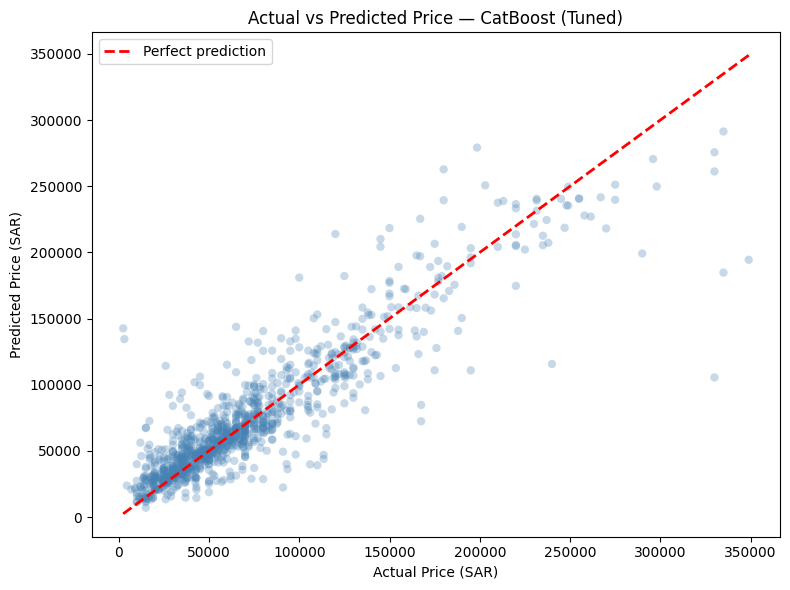

In [53]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', edgecolors='none')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Price (SAR)')
plt.ylabel('Predicted Price (SAR)')
plt.title('Actual vs Predicted Price — CatBoost (Tuned)')
plt.legend()
plt.tight_layout()
plt.show()

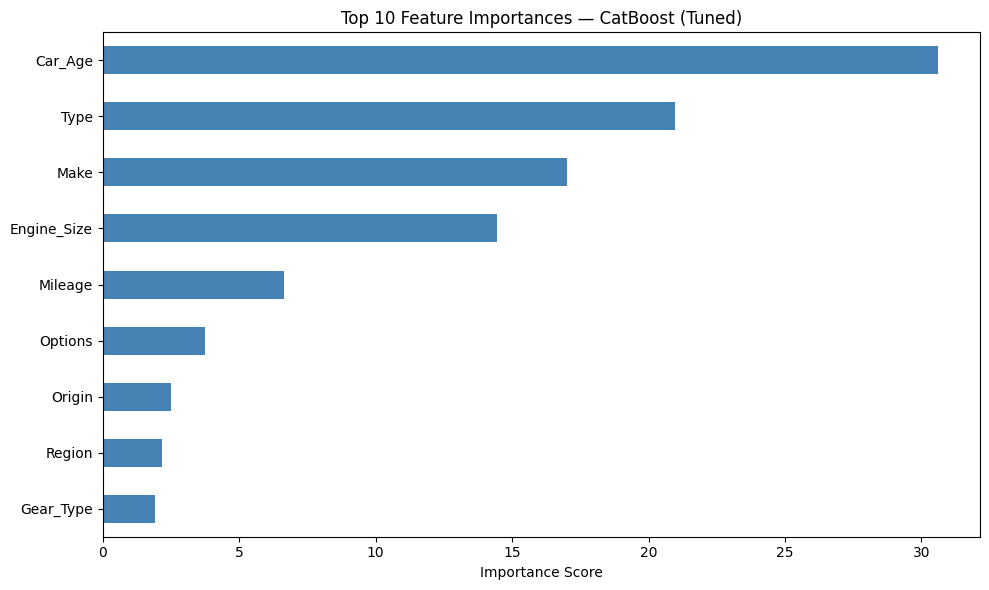


Top 10 features:
Car_Age        30.615659
Type           20.968807
Make           17.008697
Engine_Size    14.430508
Mileage         6.637399
Options         3.762923
Origin          2.488659
Region          2.163911
Gear_Type       1.923436
dtype: float64


In [54]:
importances = final_model.named_steps['model'].feature_importances_
feat_imp    = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(10).plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances — CatBoost (Tuned)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 10 features:')
print(feat_imp.head(10))

In [55]:
import pickle

filename = 'model_saudi_used_cars.sav'
pickle.dump(final_model, open(filename, 'wb'))
print(f'Model saved as: {filename}')

Model saved as: model_saudi_used_cars.sav


# Conclusion

Based on the modeling performed, the final CatBoost model with
hyperparameter tuning achieves the following performance on the
test set:

| Metric | Score |
|---|---|
| RMSE | SAR 23,338 |
| MAE  | SAR 14,317 |
| MAPE | 35.6%      |

On average, the model predicts used car prices with an error of
SAR 14,317 (MAE) — meaning if a car's actual market value is
SAR 60,000, the model will typically predict between SAR 46,000
and SAR 74,000. For Syarah.com, this level of accuracy is
sufficient to serve as an automated price recommendation tool
that guides sellers toward a fair market range, reducing the
risk of significantly overpriced or underpriced listings.

From the feature importance analysis, the most influential
factors on used car price are:

- **Car_Age (30.6%)** — the older the car, the lower the price.
  Age is the single strongest driver of depreciation in this
  dataset, validating the decision to engineer Car_Age from
  the raw Year column.
- **Type (21.0%) and Make (17.0%)** — the specific car model
  and brand together account for 38% of prediction importance.
  A Toyota Land Cruiser and a Toyota Corolla are priced
  completely differently despite sharing the same manufacturer.
- **Engine_Size (14.4%)** — larger engines command higher prices,
  consistent with the Saudi market's preference for SUVs and
  pickup trucks.
- **Mileage (6.6%)** — lower than expected because Car_Age
  already captures most of the depreciation signal. Age and
  mileage are correlated, and the model learned that age is
  the more reliable indicator.

# Recommendations

**When the model can be trusted:**
The model is most reliable for mainstream used cars listed on
Syarah.com with complete feature data — particularly common
makes and types such as Toyota, Hyundai, Ford, and Chevrolet
that are well-represented in the training data. Predictions
for cars with Car_Age between 3 and 15 years and Mileage
between 20,000 and 400,000 km fall within the model's
strongest range.

**When the model should be used with caution:**
- Cars with rare makes or model types not well-represented
  in the dataset — these were grouped as 'Other' and the
  model has limited pricing knowledge for them
- Electric vehicles — no EVs exist in this dataset, yet EVs
  are increasingly influencing global used car market dynamics.
  The model cannot price EVs reliably and should not be applied
  to them without retraining
- Periods of significant macroeconomic change — fuel price
  fluctuations, government import regulations, or global supply
  chain disruptions can shift car prices in ways the model
  cannot account for without updated training data

**Recommendations for improvement:**

1. **Periodic retraining** — the model should be retrained on
   fresh Syarah.com listing data every 6–12 months to reflect
   current market conditions. Car_Age is recalculated at
   retraining time, keeping the age feature always current.

2. **Add EV data** — as electric vehicles enter the Saudi market,
   listing data for EVs should be collected and incorporated
   into future training datasets. EV pricing follows different
   depreciation curves than combustion engine vehicles.

3. **Incorporate external signals** — features such as fuel
   price index, new car sales volume, or import tariff changes
   could be added as model inputs to capture macroeconomic
   effects on used car prices.

4. **Confidence interval output** — rather than predicting a
   single price, the model could output a price range
   (e.g. SAR 55,000 – SAR 65,000). This would better serve
   negotiable listings and give buyers a clearer sense of
   fair market value.

5. **Condition rating feature** — the current dataset has no
   information about physical car condition. Adding a
   seller-reported condition score (e.g. Excellent / Good /
   Fair / Poor) at listing time could significantly reduce
   prediction error, as physical condition is one of the
   strongest real-world price drivers not currently captured.